In [7]:
#Loading the Preprocessed Logistics Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df = pd.read_csv("Delivery_Logistics_updated.csv")
print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (25000, 15)


,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600


In [6]:
#Descriptive Statistical Analysis
numerical_columns = [
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_rating",
    "delivery_cost"
]
summary = df[numerical_columns].describe().T
summary["median"] = df[numerical_columns].median()
display(summary)

,count,mean,std,min,25%,50%,75%,max,median
distance_km,25000.0,150.390436,86.409745,3.6000,75.90,151.000,224.90,297.1000,151.000
package_weight_kg,25000.0,25.145898,14.368663,0.6700,12.68,25.145,37.66,49.5200,25.145
delivery_time_hours,25000.0,6.248040,3.140935,0.0000,4.00,6.000,8.00,19.0000,6.000
expected_time_hours,25000.0,13.107680,7.559024,2.0000,8.00,8.000,16.00,24.0000,8.000
delivery_rating,25000.0,3.666000,1.149964,1.0000,3.00,4.000,5.00,5.0000,4.000
delivery_cost,25000.0,864.944579,435.712593,95.6674,490.80,867.535,1237.91,1632.7206,867.535


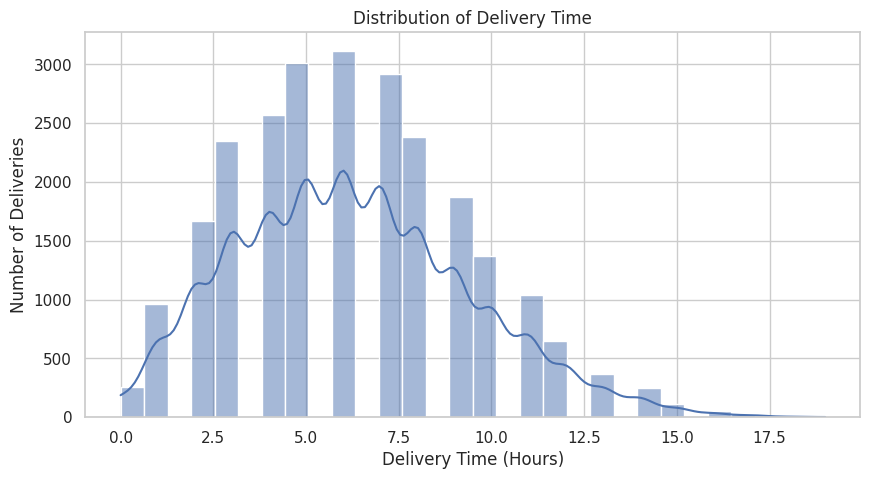

In [8]:
#Distribution of Delivery Time
plt.figure(figsize=(10,5))
sns.histplot(
    df["delivery_time_hours"],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Hours)")
plt.ylabel("Number of Deliveries")
plt.show()

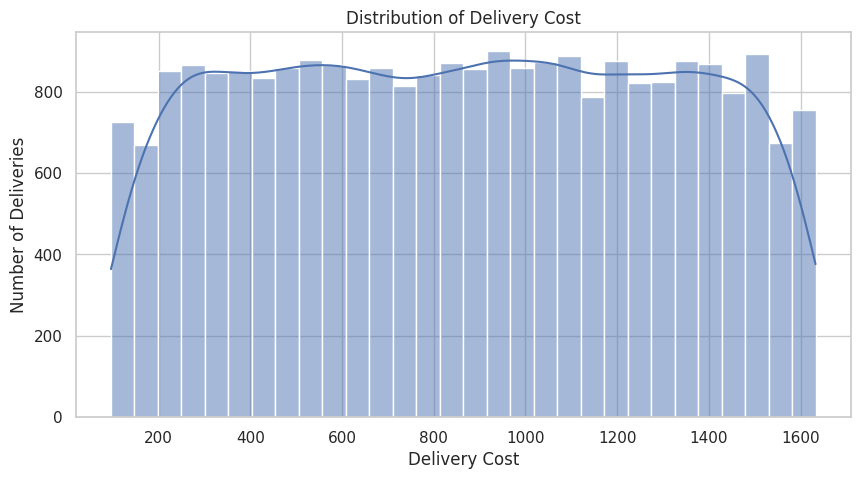

In [9]:
#Distribution of Delivery Cost
plt.figure(figsize=(10,5))
sns.histplot(
    df["delivery_cost"],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Cost")
plt.xlabel("Delivery Cost")
plt.ylabel("Number of Deliveries")
plt.show()

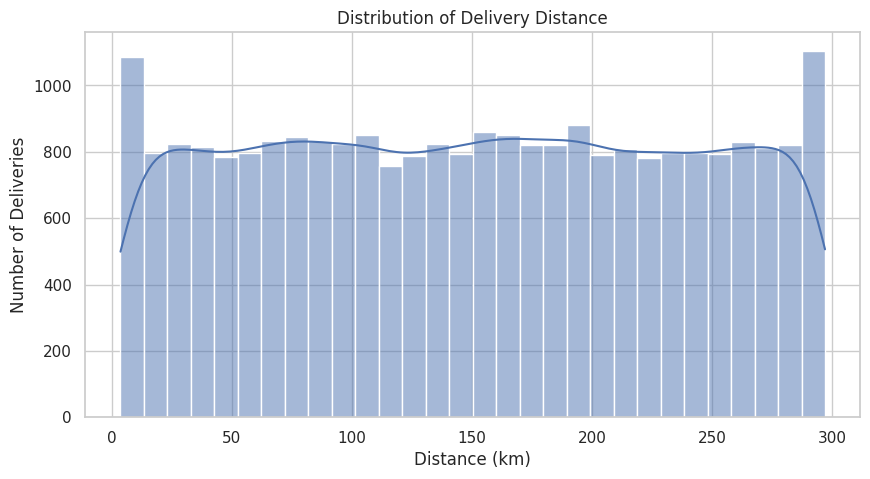

In [10]:
#Distribution of Delivery Distance
plt.figure(figsize=(10,5))
sns.histplot(
    df["distance_km"],
    bins=30,
    kde=True
)
plt.title("Distribution of Delivery Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Deliveries")
plt.show()

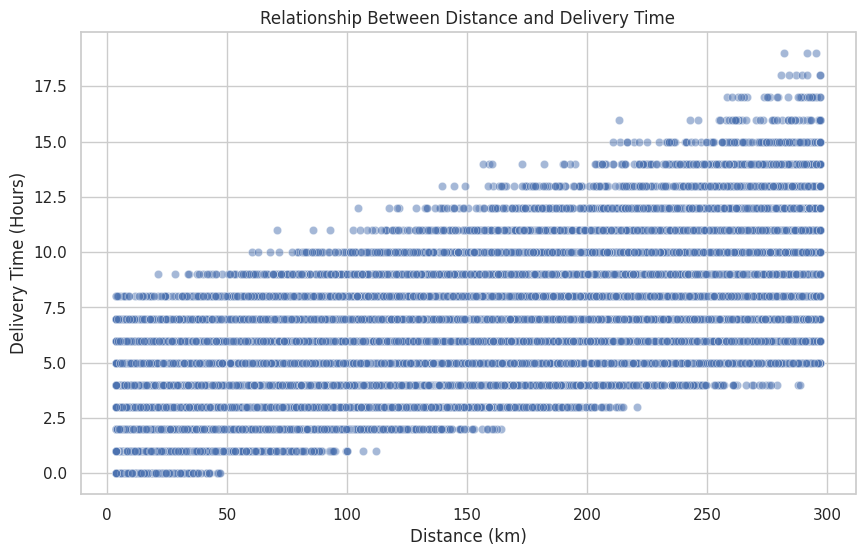

,distance_km,delivery_time_hours
distance_km,1.000000,0.685883
delivery_time_hours,0.685883,1.000000


In [11]:
#Relationship Between Delivery Distance and Delivery Time
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_time_hours",
    alpha=0.5
)
plt.title("Relationship Between Distance and Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (Hours)")
plt.show()

correlation = df[
    ["distance_km", "delivery_time_hours"]
].corr()
display(correlation)

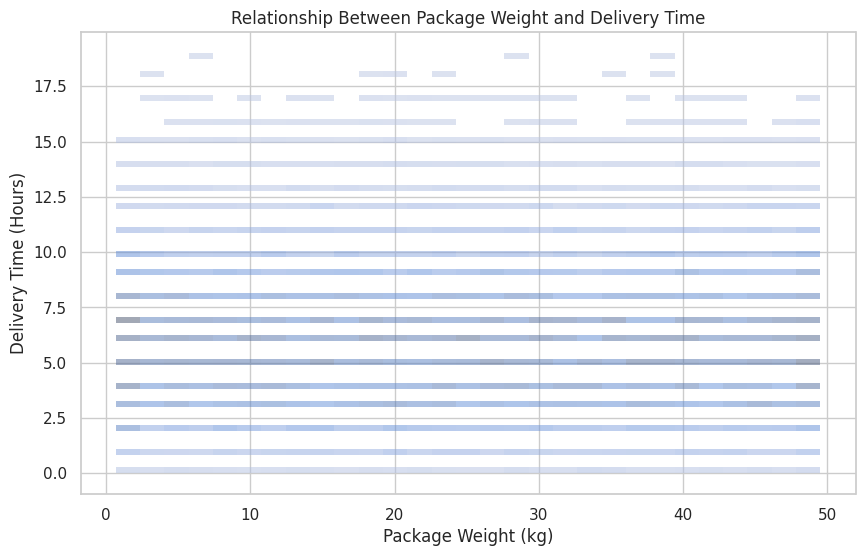

In [12]:
#Relationship Between Package Weight and Delivery Time
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="package_weight_kg",
    y="delivery_time_hours",
    alpha=0.5
)
plt.title("Relationship Between Package Weight and Delivery Time")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Time (Hours)")
plt.show()


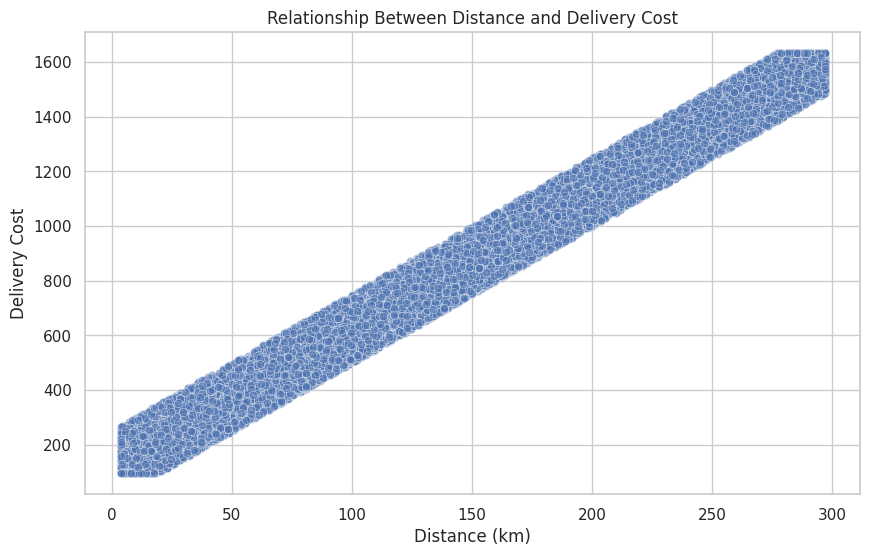

In [ ]:
#Relationship Between Distance and Delivery Cost
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="distance_km",
    y="delivery_cost",
    alpha=0.5
)
plt.title("Relationship Between Distance and Delivery Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")
plt.show()

,delivery_time_hours,expected_time_hours,delivery_time_difference
0,8,8,0
1,2,3,-1
2,10,16,-6
3,6,8,-2
4,9,16,-7


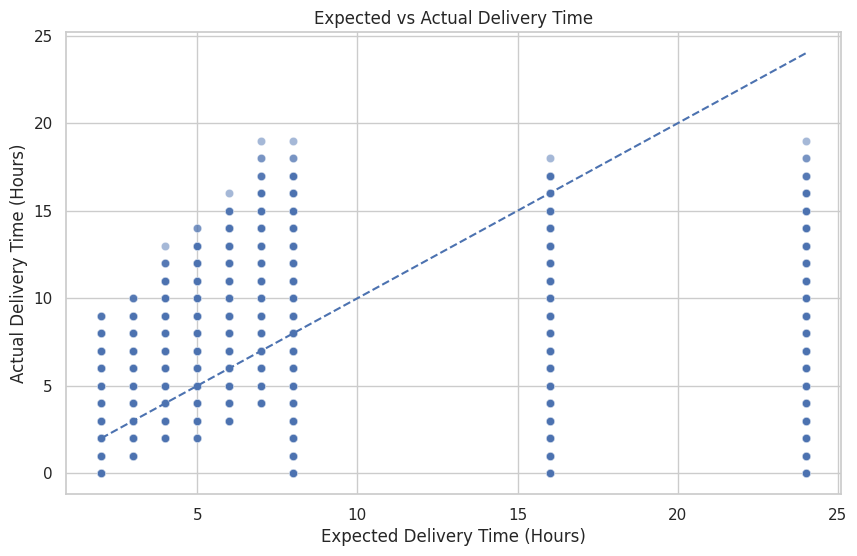

In [ ]:
#Comparison of Expected and Actual Delivery Time
df["delivery_time_difference"] = (
    df["delivery_time_hours"]
    - df["expected_time_hours"]
)
display(
    df[
        [
            "delivery_time_hours",
            "expected_time_hours",
            "delivery_time_difference"
        ]
    ].head()
)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="expected_time_hours",
    y="delivery_time_hours",
    alpha=0.5
)
plt.plot(
    [df["expected_time_hours"].min(),
     df["expected_time_hours"].max()],
    [df["expected_time_hours"].min(),
     df["expected_time_hours"].max()],
    linestyle="--"
)
plt.title("Expected vs Actual Delivery Time")
plt.xlabel("Expected Delivery Time (Hours)")
plt.ylabel("Actual Delivery Time (Hours)")
plt.show()

,delivery_partner,Total_Deliveries,Average_Delivery_Time,Average_Cost,Average_Rating
6,fedex,2818,6.140880,857.355640,3.698368
2,delhivery,2786,6.155420,848.109810,3.687724
4,ecom express,2722,6.246877,868.772186,3.674504
3,dhl,2802,6.250535,872.831125,3.685225
5,ekart,2801,6.268119,869.966720,3.655480
7,shadowfax,2736,6.272295,868.340156,3.661550
0,amazon logistics,2711,6.279233,868.150131,3.644412
1,blue dart,2798,6.296283,863.021705,3.677627
8,xpressbees,2826,6.323779,868.165768,3.608988


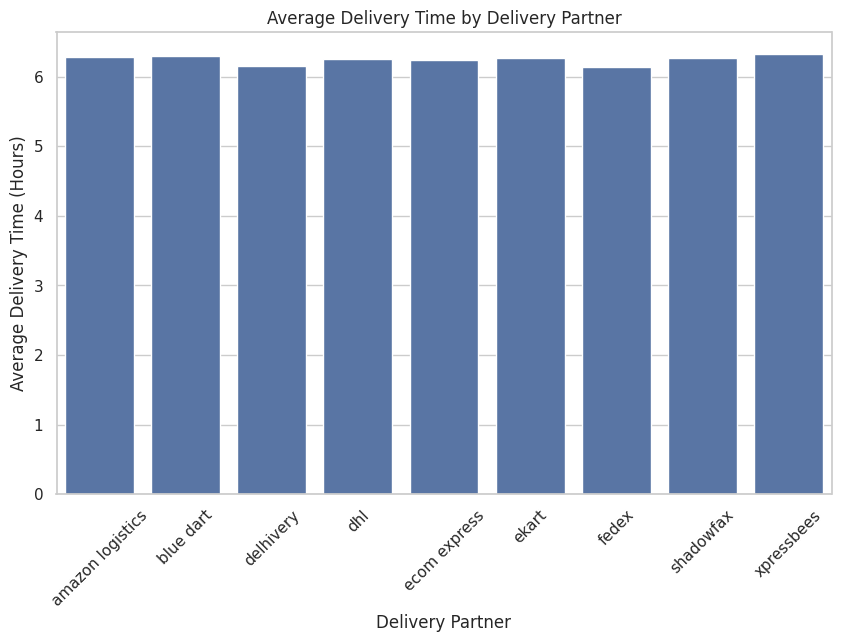

In [ ]:
#Delivery Partner Performance Analysis
partner_analysis = df.groupby(
    "delivery_partner"
).agg(
    Total_Deliveries=("delivery_partner", "size"),
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Cost=("delivery_cost", "mean"),
    Average_Rating=("delivery_rating", "mean")
).reset_index()
display(
    partner_analysis.sort_values(
        "Average_Delivery_Time"
    )
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=partner_analysis,
    x="delivery_partner",
    y="Average_Delivery_Time"
)
plt.title("Average Delivery Time by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=45)
plt.show()

,vehicle_type,Total_Deliveries,Average_Delivery_Time,Average_Distance,Average_Cost
0,bike,4160,6.277644,151.423462,868.917038
1,ev bike,4218,6.197013,151.044500,869.235484
2,ev van,4116,6.250000,150.679057,866.181463
3,scooter,4174,6.278869,150.160541,862.914003
4,truck,4145,6.217129,150.265549,864.768182
5,van,4187,6.267972,148.774254,857.658050


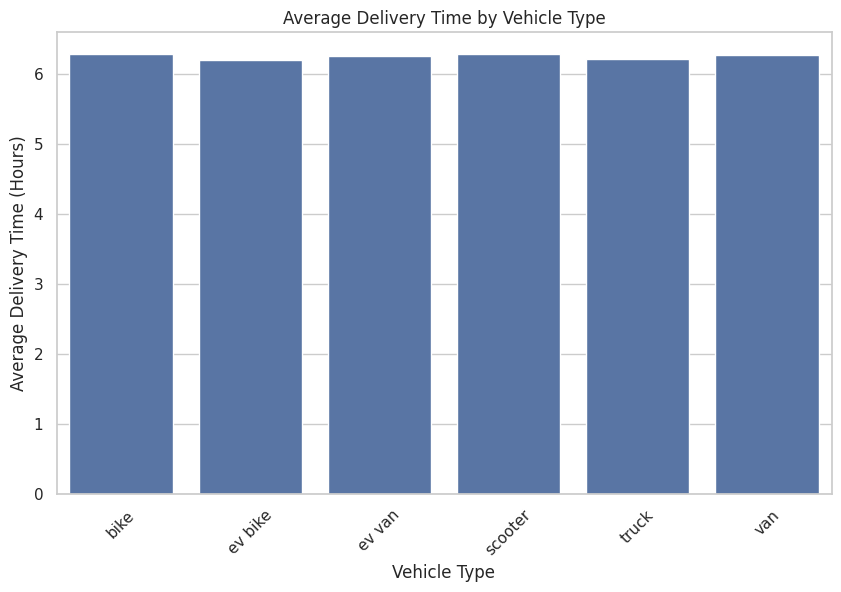

In [13]:
#Vehicle Type Performance Analysis
vehicle_analysis = df.groupby(
    "vehicle_type"
).agg(
    Total_Deliveries=("vehicle_type", "size"),
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Distance=("distance_km", "mean"),
    Average_Cost=("delivery_cost", "mean")
).reset_index()
display(vehicle_analysis)

plt.figure(figsize=(10,6))
sns.barplot(
    data=vehicle_analysis,
    x="vehicle_type",
    y="Average_Delivery_Time"
)
plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=45)
plt.show()

In [14]:
#Regional Logistics Performance Analysis
region_analysis = df.groupby(
    "region"
).agg(
    Total_Deliveries=("region", "size"),
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Cost=("delivery_cost", "mean"),
    Average_Rating=("delivery_rating", "mean")
).reset_index()
display(region_analysis)



,region,Total_Deliveries,Average_Delivery_Time,Average_Cost,Average_Rating
0,central,5060,6.283004,869.950989,3.660672
1,east,4919,6.213458,861.455929,3.682252
2,north,4949,6.249141,860.439223,3.679935
3,south,4977,6.196102,858.296324,3.667671
4,west,5095,6.296369,874.211232,3.640432


,weather_condition,Total_Deliveries,Average_Delivery_Time,Average_Cost
0,clear,4124,4.776431,865.366973
1,cold,4158,4.773449,866.776034
2,foggy,4219,6.486608,862.682236
3,hot,4130,4.784504,868.231080
4,rainy,4171,7.804843,867.469355
5,stormy,4198,8.807527,859.247482


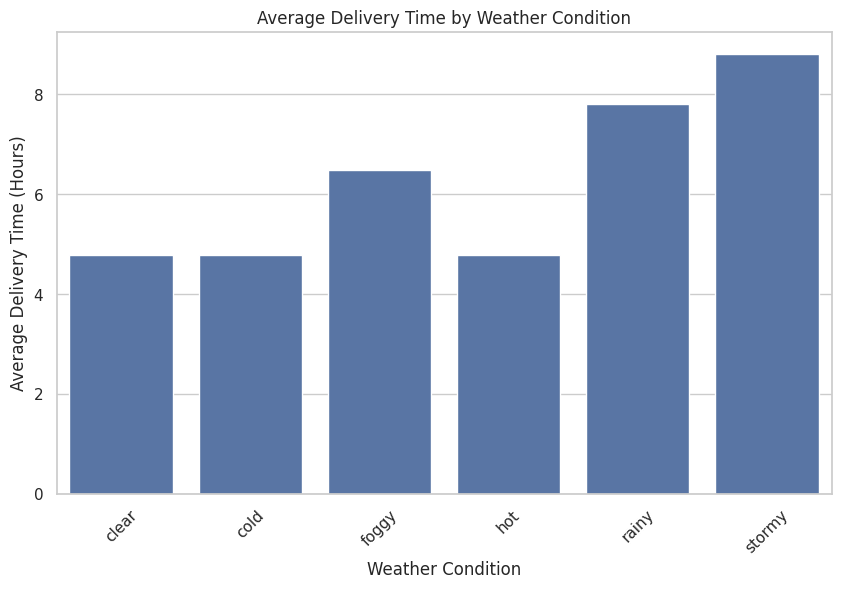

In [17]:
#Impact of Weather Conditions on Delivery Performance
weather_analysis = df.groupby(
    "weather_condition"
).agg(
    Total_Deliveries=("weather_condition", "size"),
    Average_Delivery_Time=("delivery_time_hours", "mean"),
    Average_Cost=("delivery_cost", "mean")
).reset_index()
display(weather_analysis)

plt.figure(figsize=(10,6))
sns.barplot(
    data=weather_analysis,
    x="weather_condition",
    y="Average_Delivery_Time"
)
plt.title("Average Delivery Time by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Average Delivery Time (Hours)")
plt.xticks(rotation=45)
plt.show()

In [21]:
#Overall Delivery Delay Analysis
delay_percentage = (
    df["delayed"]
    .value_counts(normalize=True)
    * 100
)
print("Delivery Delay Percentage:")
display(delay_percentage)
#Delay Distribution by Region
delay_by_region = pd.crosstab(
    df["region"],
    df["delayed"],
    normalize="index"
) * 100
display(delay_by_region)
#Delay Distribution by Weather Condition
delay_by_weather = pd.crosstab(
    df["weather_condition"],
    df["delayed"],
    normalize="index"
) * 100
display(delay_by_weather)



Delivery Delay Percentage:


,proportion
delayed,
no,73.324
yes,26.676


delayed,no,yes
region,,
central,72.747036,27.252964
east,74.202074,25.797926
north,73.428976,26.571024
south,73.216797,26.783203
west,73.052012,26.947988


delayed,no,yes
weather_condition,,
clear,82.565470,17.434530
cold,83.982684,16.017316
foggy,69.684759,30.315241
hot,82.881356,17.118644
rainy,62.646847,37.353153
stormy,58.551691,41.448309


,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost
distance_km,1.000000,0.002311,0.685883,0.045236,-0.132634,0.990772
package_weight_kg,0.002311,1.000000,0.001242,0.001442,-0.002891,0.099479
delivery_time_hours,0.685883,0.001242,1.000000,0.039755,-0.272637,0.678911
expected_time_hours,0.045236,0.001442,0.039755,1.000000,0.462872,-0.025480
delivery_rating,-0.132634,-0.002891,-0.272637,0.462872,1.000000,-0.160679
delivery_cost,0.990772,0.099479,0.678911,-0.025480,-0.160679,1.000000


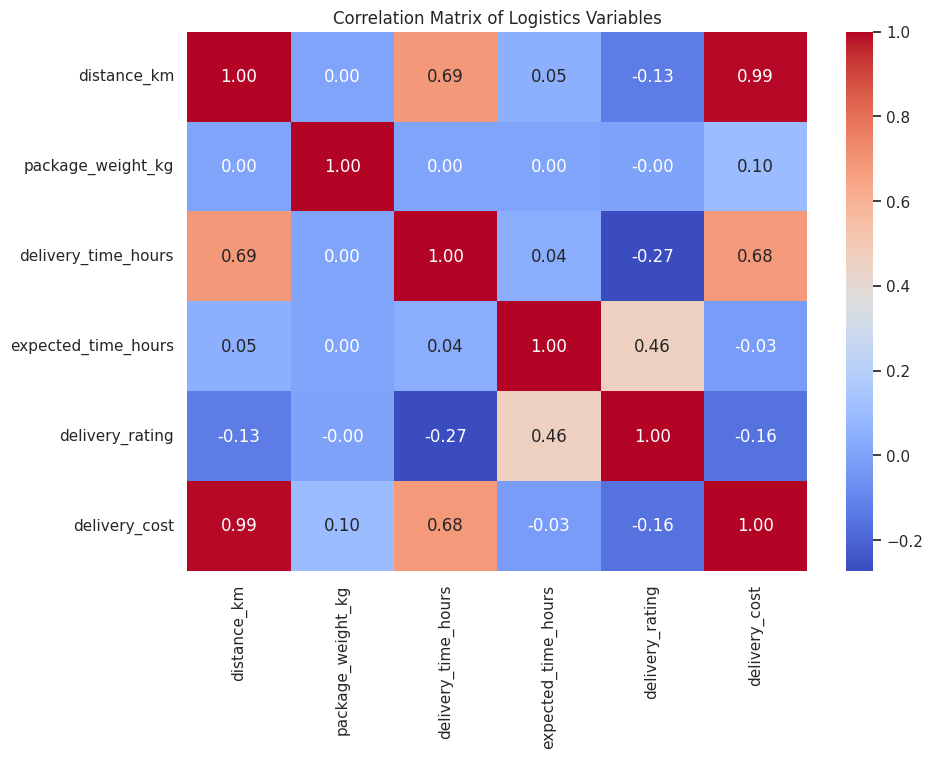

In [24]:
#Correlation Analysis of Logistics Variables
correlation_matrix = df[
    numerical_columns
].corr()
display(correlation_matrix)
plt.figure(figsize=(10,7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Logistics Variables")
plt.show()